# Analyse multidimensionnelle des trajectoires de soins pour le jeu de données Synthea

Ce notebook présente l'application du package `trajectoryclusteringanalysis` sur un jeu de données de prescriptions de médicaments exprimé en jours.

1. Configuration de l'environnement et imports
2. Chargement et préparation des données
3. Initialisation du modèle TCA et construction du tenseur
4. Décomposition par l'algorithme SWoTTeD
5. Clustering sur les intensités des phénotypes

Les données utilisées ont été générées par Synthea. 
> Walonoski J, Klaus S, Granger E, Hall D, Gregorowicz A, Neyarapally G, Watson A, Eastman J. *Synthea™ Novel coronavirus (COVID-19) model and synthetic data set*. Intelligence-Based Medicine. 2020 Nov;1:100007. [https://doi.org/10.1016/j.ibmed.2020.100007](https://doi.org/10.1016/j.ibmed.2020.100007)

## 1. Imports

In [6]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import random

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA

Using local package from: c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


## 2. Chargement et préparation des données

In [7]:
df_synthea = pd.read_csv(project_root / "data" / "multidimensional_synthea_10k.csv")
df_synthea['time'] = df_synthea['time'].clip(upper=20)

# Dictionnaire pour simplifier les noms des médicaments
medication_mapping = {
    'NDA020503 200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler': 'Albuterol Inhaler',
    '120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler': 'Fluticasone Inhaler',
    'insulin human  isophane 70 UNT/ML / Regular Insulin  Human 30 UNT/ML Injectable Suspension [Humulin]': 'Insulin',
    '24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet': 'Metformin',
    'Hydrochlorothiazide 25 MG Oral Tablet': 'HCTZ 25mg',
    'amLODIPine 5 MG / Hydrochlorothiazide 12.5 MG / Olmesartan medoxomil 20 MG Oral Tablet': 'Amlodipine Combo',
    'Atenolol 50 MG / Chlorthalidone 25 MG Oral Tablet': 'Atenolol Combo',
    'Hydrochlorothiazide 12.5 MG': 'HCTZ 12.5mg',
    'Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray': 'Nitroglycerin Spray',
    'Simvastatin 10 MG Oral Tablet': 'Simvastatin 10mg'
}

df_synthea['medication_events'] = df_synthea['medication_events'].map(medication_mapping)


print(f"Nombre de patients : {df_synthea['patient_id'].nunique()}")
print(f"Temps de suivi max (jours) : {df_synthea['time'].max()}")
df_synthea.head()

Nombre de patients : 901
Temps de suivi max (jours) : 20


,patient_id,time,medication_events
0,1,11,Fluticasone Inhaler
1,1,11,Albuterol Inhaler
2,1,20,Fluticasone Inhaler
3,1,20,Albuterol Inhaler
4,1,20,Fluticasone Inhaler


## 3. Initialisation du modèle TCA

In [8]:
label_encoder = LabelEncoder()
timed_event_structure = df_synthea.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['medication_events'])
timed_event_structure.drop(columns=['medication_events'], inplace=True)

timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
noms_events = label_encoder.classes_

tca = TCA(data=timed_event_structure,
          index_col='ID_PATIENT',
          time_col='Time', 
          event_col='Event',
          mode='multidimensional'
         )

tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (30753, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3
4      4              4
5      5              5
6      6              6
7      7              7
8      8              8
9      9              9
Tensor shape: torch.Size([901, 10, 21])


On peut visualiser la trajectoires de soins d'un des patients du tenseur.

Patient utilisé pour la visualisation: 21


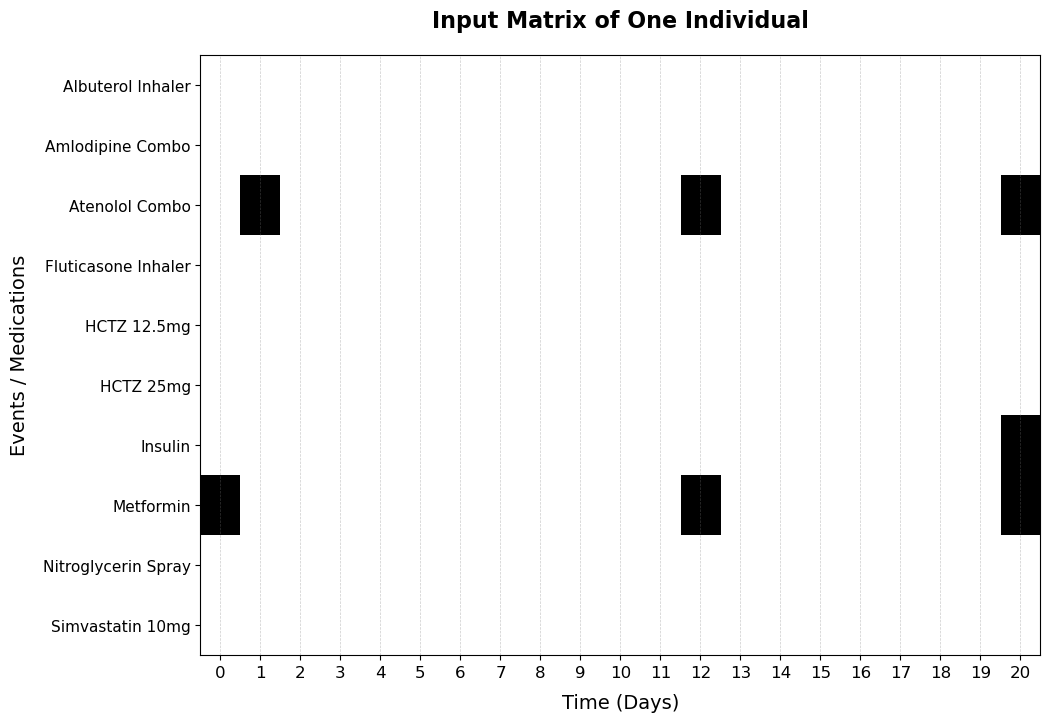

In [9]:
# Un patient avec au moins 3/4 traitements diff.
patients_complexes = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: len(set(group['Event'])) >= 3
)['ID_PATIENT'].unique()

patient_index = int(patients_complexes[0])
print(f"Patient utilisé pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=noms_events, time_unit="Days")

## 4. Décomposition du jeu de données à l'aide de l'algorithme SWOTTED

On souhaite décomposer le jeu de données en plusieurs phénotypes, on peut faire varier la durée de ces phénotypes ainsi que leurs nombres afin de faire un clustering par la suite.

In [10]:
# Hyperparametres de la demo
metric = 'Bernoulli'
learning_rate = 1e-2
n_epochs = 2  # 30 pour demo rapide, 100+ pour entrainement plus stable

In [11]:
ranks = [2, 3, 4, 5]
windows = [5, 7, 10, 12, 15]
sparsities = [0.1, 0.3, 0.5, 0.7, 0.9]
non_successions = [0.1, 0.3, 0.5, 0.7, 0.9]
models = {}

# Nombre max de tests
n_essais_max = 10 


for i in range(n_essais_max):
    r = random.choice(ranks)
    w = random.choice(windows)
    s = random.choice(sparsities)
    ns = random.choice(non_successions)
    
    print(f"\n--- Essai {i+1}/{n_essais_max} : R={r}, W={w}, S={s}, NS={ns} ---")
    
    tca.analyzer.fit_swotted_decomposition(
        tensor, rank=r, time_window_length=w, 
        reg_term_ns=ns, reg_term_s=s, metric=metric, 
        learning_rate=learning_rate, n_epochs=n_epochs, fit_metric_every_n_epochs=0 
    )

    models[(r, w, s, ns)] = (tca.analyzer.model, tca.analyzer.W)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelChec


--- Essai 1/10 : R=2, W=12, S=0.3, NS=0.9 ---


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/2 - train_loss: 78.464302
Epoch 2/2 - train_loss: 35.330601


...

`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 400    | n/a   | n/a  
---------------------------------------------------------------
400       Trainable params
0         Non-trainable params
400       Total params
0.002     Total estimated model params size (MB)
1         


--- Essai 10/10 : R=4, W=10, S=0.1, NS=0.3 ---


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/2 - train_loss: 127.027687
Epoch 2/2 - train_loss: 30.945604


`Trainer.fit` stopped: `max_epochs=2` reached.


Les matrices reconstruites ne sont pas très bonnes même pour 200 époques

Decomposed into 901 pathways with rank 5 and time window length 7
Success rate for the entire dataset: -0.0266


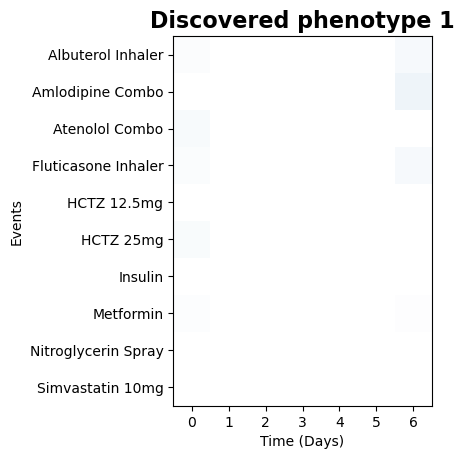

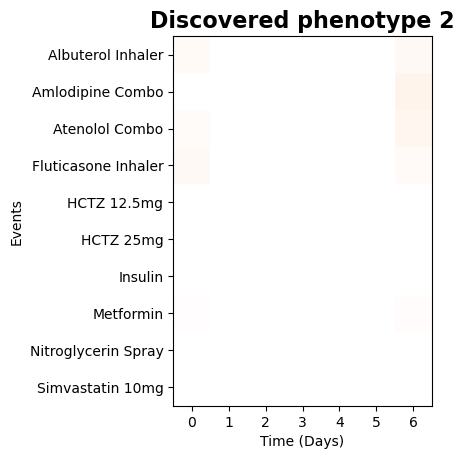

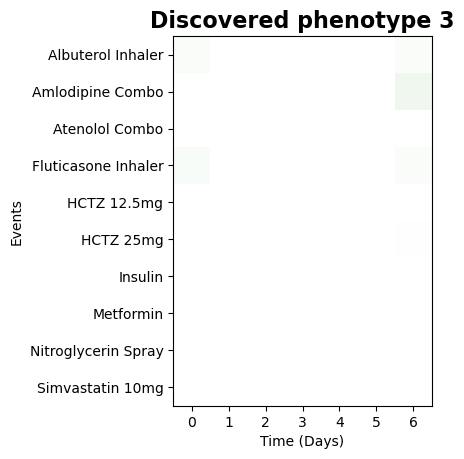

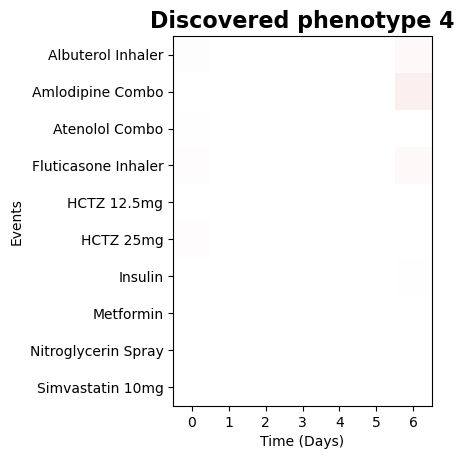

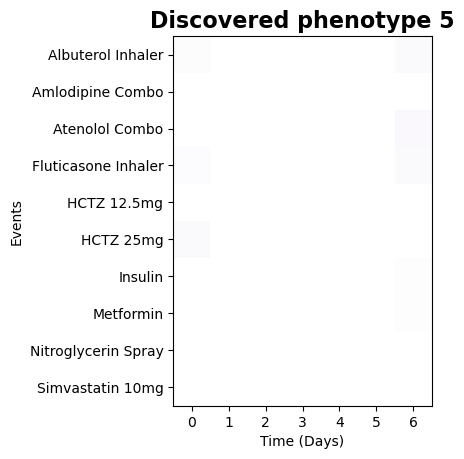

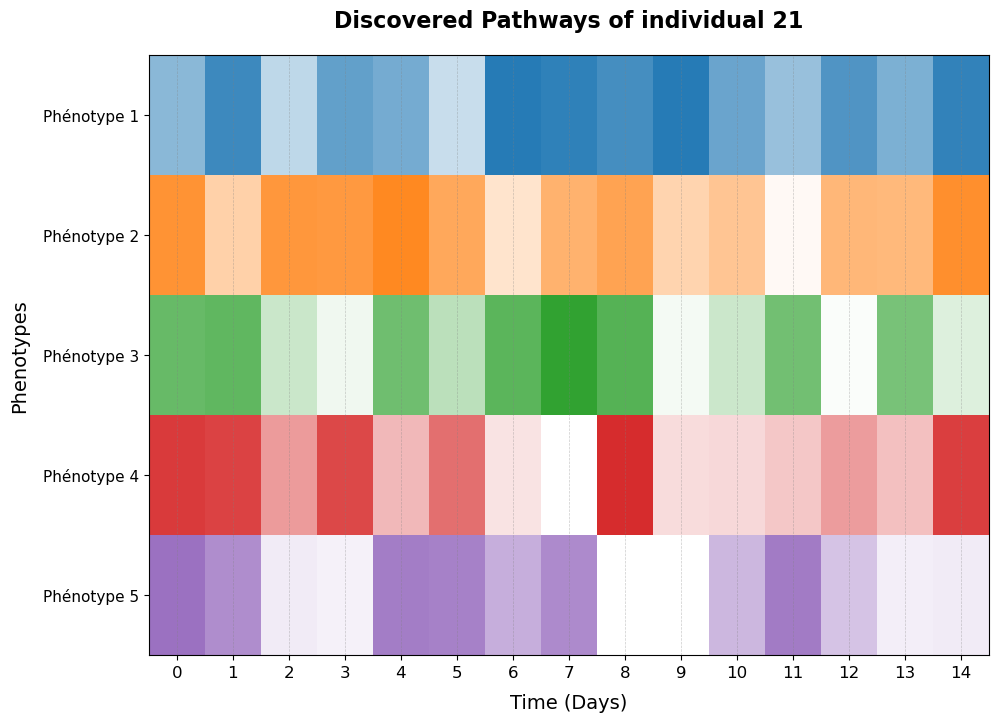

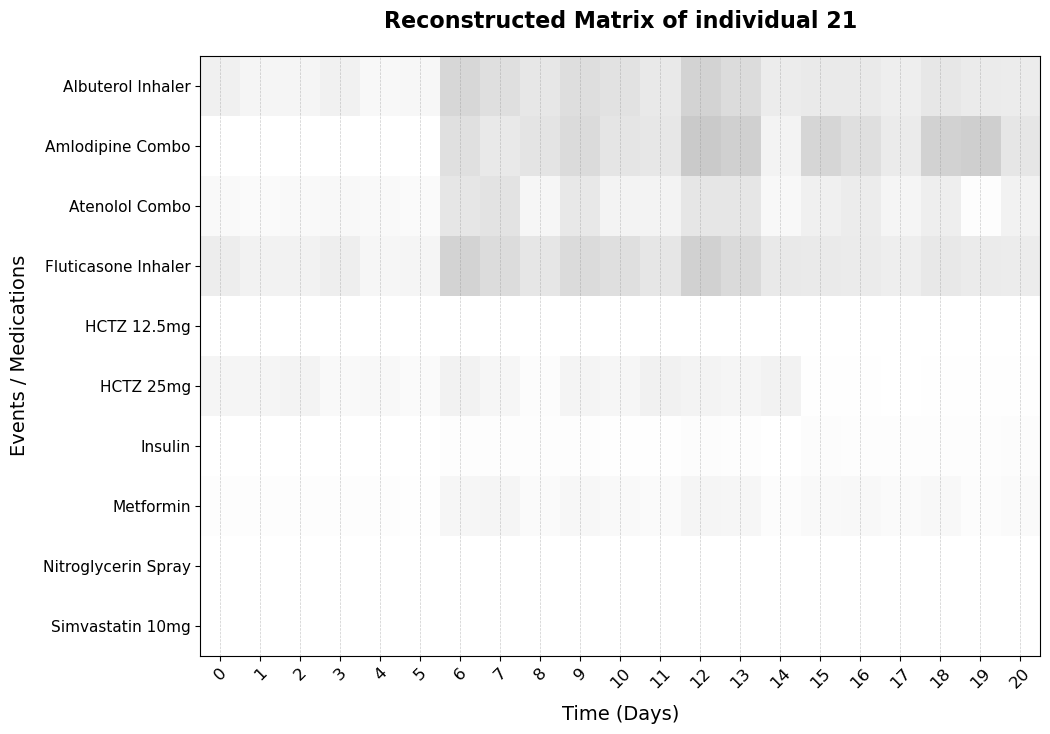

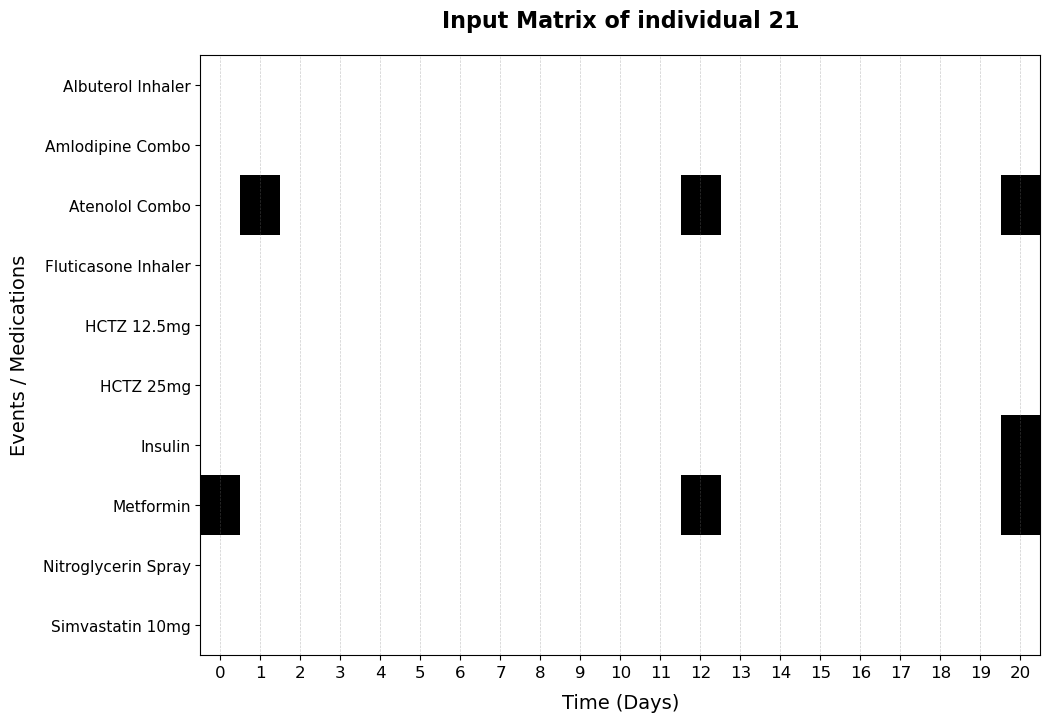

In [12]:
best_rank = 5
best_window = 7
best_reg_term_s = 0.1
best_reg_term_ns = 0.1

tca.analyzer.model, tca.analyzer.W = models[(best_rank, best_window, best_reg_term_s, best_reg_term_ns)]
tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index, time_unit='Days')

## 5. Clustering

### 5.1. Intensités des phénotypes :

In [15]:
from sklearn.preprocessing import MinMaxScaler
ph_intensity = tca.analyzer.to_phenotype_intensity(scaler=MinMaxScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (721, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,0.006701,0.496355,0.000000,1
1,1.000000,0.075938,0.999386,2
2,0.308419,0.000000,0.002956,3
3,0.645913,1.000000,0.011201,4
4,0.000589,0.000000,0.841440,5


### 5.2. Clustering à partir des intensités :

INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.00 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:238: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


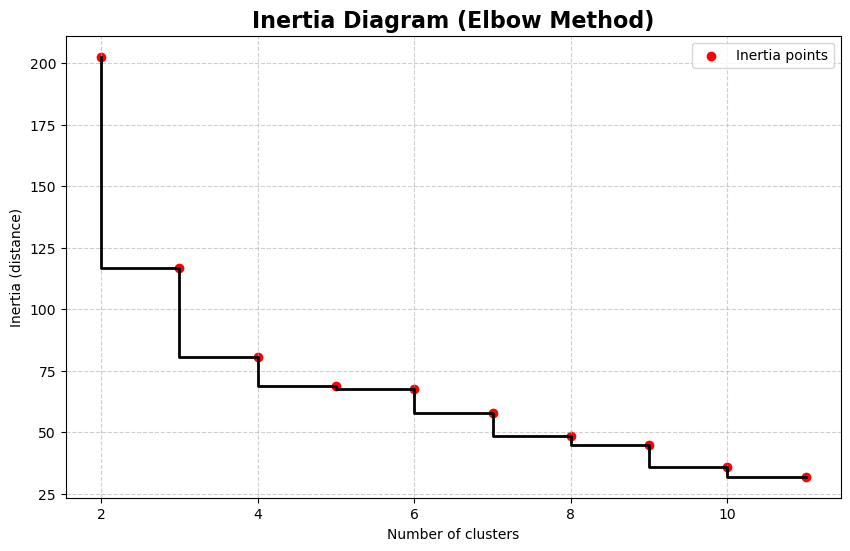

In [16]:
distance_matrix = tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca.hierarchical_clustering(distance_matrix)
tca.plot_inertia(linkage_matrix)

On choisit le nombre de clusters grâce au plot de l'inertie, ici cela semble intéressant de choisir 4 clusters.

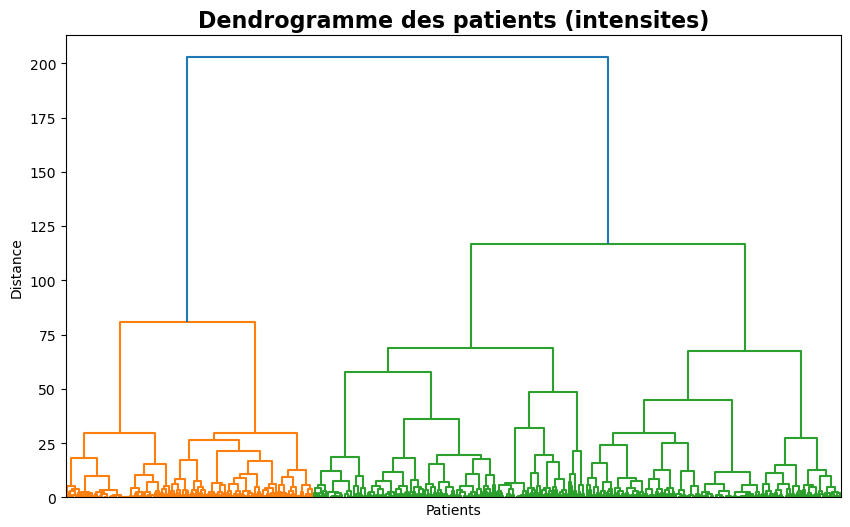

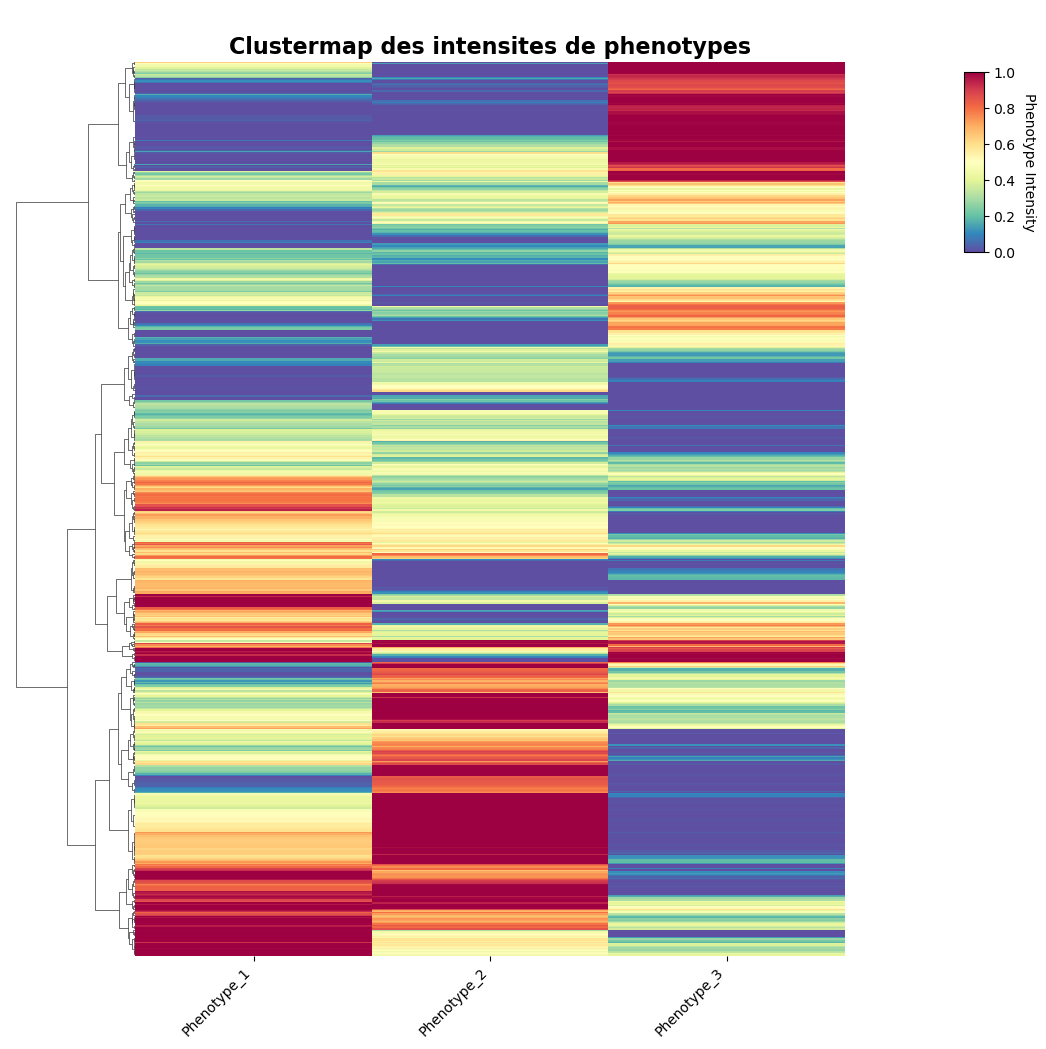

Effectifs par cluster:
1     97
2    133
3    254
4    237
Name: count, dtype: int64


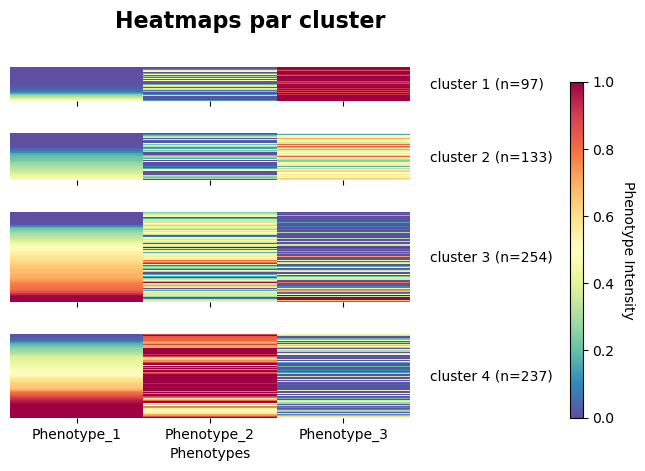

In [26]:
tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

clusters = tca.assign_clusters(linkage_matrix, num_clusters=4)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')

On peut compter la moyenne des différents médicaments par cluster, pour voir si un cluster est représenté par la présence de nombreux médicaments

In [27]:
nb_meds = timed_event_structure.groupby('ID_PATIENT')['Event'].nunique()
for c in sorted(set(clusters)):
    ids = ph_intensity[np.array(clusters) == c]['ID_PATIENT']
    print(f"Cluster {c} — nb médicaments moyen : {nb_meds[ids].mean():.2f}")

Cluster 1 — nb médicaments moyen : 1.58
Cluster 2 — nb médicaments moyen : 1.43
Cluster 3 — nb médicaments moyen : 1.64
Cluster 4 — nb médicaments moyen : 2.00


On peut aussi voir quel médicament a été prescrit en premier pour chaque patient des clusters.

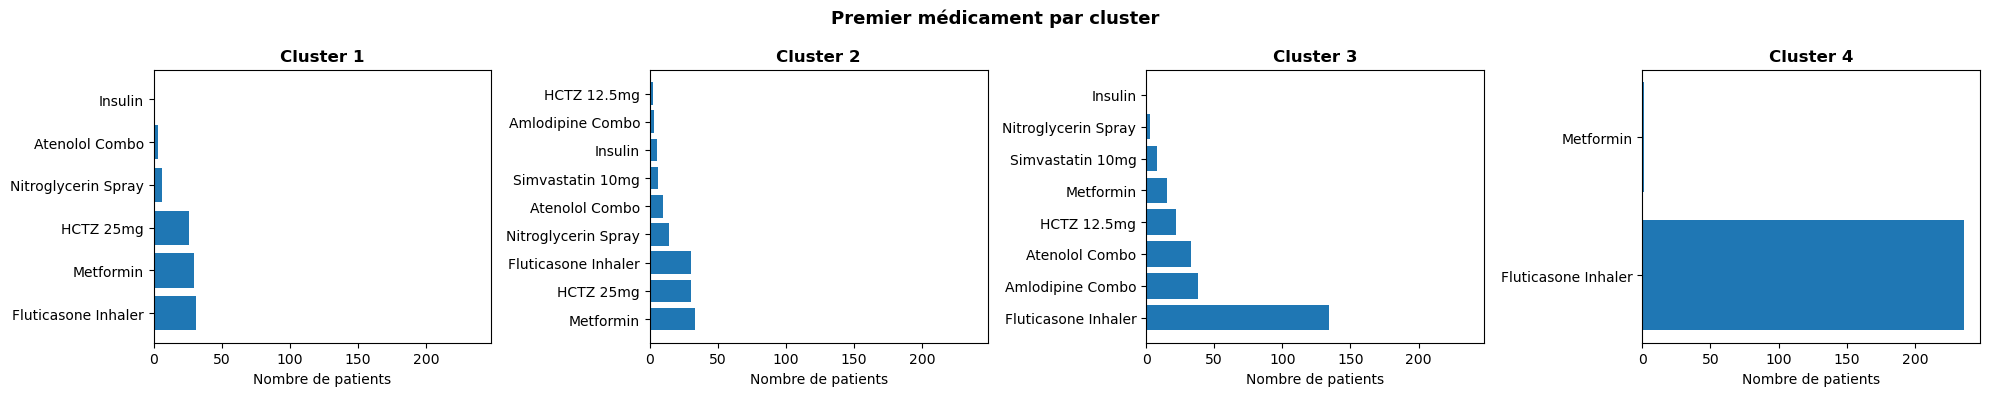

In [28]:
first_med = timed_event_structure.groupby('ID_PATIENT').apply(
    lambda x: x.loc[x['Time'].idxmin(), 'Event']
).map(dict(enumerate(noms_events)))

fig, axes = plt.subplots(1, len(set(clusters)), figsize=(5 * len(set(clusters)), 4), squeeze=False, sharex=True)

for ax, c in zip(axes[0], sorted(set(clusters))):
    ids = ph_intensity[np.array(clusters) == c]['ID_PATIENT']
    counts = first_med[ids].value_counts()
    ax.barh(counts.index, counts.values)
    ax.set_title(f"Cluster {c}", fontweight='bold')
    ax.set_xlabel("Nombre de patients")

plt.suptitle("Premier médicament par cluster", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()